# 2026 07 22 Python 실습 코드

In [1]:
from tensorflow.keras.preprocessing.text import Tokenizer  # 토큰화 모듈 => 정수 인코딩
from tensorflow.keras.utils import to_categorical   # 원-핫 인코딩 모듈

I0000 00:00:1784693158.079069   50654 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784693158.529636   50654 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784693161.557004   50654 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
texts = ['딥러닝을 학습하고 있습니다.',
         '인공지능을 학습하고 있습니다',
         '자연어 처리 방법을 학습하고 있습니다.']

# Tokenizer 함수를 이용해서 토큰화
- oov_token: 데이터에 나타나지 않은 단어를 전달된 단어로 교체
- fit_on_texts() 함수를 통해 데이터에 적용하고, texts_to_sequences() 함수로 변환
- sequences_to_matrix() 함수를 사용하면 이진 형태로 인코딩(One-Hot Encoding)된 결과를 얻을 수 있음    

In [3]:
# 단어 사전에 등록되지 않은 단어는 OOV로 처리하겠다!!
tokenizer = Tokenizer(num_words=10, oov_token='<OOV>')

# 토큰화(공백 기준), 빈도수 계싼, 단어사전 생성(인덱스 부여)
tokenizer.fit_on_texts(texts)

In [4]:
# 단어사전 확인
print(tokenizer.word_index)
print(tokenizer.word_counts)

{'<OOV>': 1, '학습하고': 2, '있습니다': 3, '딥러닝을': 4, '인공지능을': 5, '자연어': 6, '처리': 7, '방법을': 8}
OrderedDict({'딥러닝을': 1, '학습하고': 3, '있습니다': 3, '인공지능을': 1, '자연어': 1, '처리': 1, '방법을': 1})


In [5]:
# 정수 인코딩 진행 -> 텍스트 데이터를 단어사전을 이용해 숫자로 표현
sequences = tokenizer.texts_to_sequences(texts)
print(f"sequence : {sequences}")

sequence : [[4, 2, 3], [5, 2, 3], [6, 7, 8, 2, 3]]


In [6]:
# One-Hot Encoding 진행
one_hot_sequences = tokenizer.texts_to_matrix(texts)
print(f"one_hot_sequences : {one_hot_sequences}")

one_hot_sequences : [[0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0. 1. 1. 1. 0.]]


- 희소 행렬과 밀집 행렬

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# padding을 이용해서 다양한 문장의 길이를 같은 문장의 크기로 일정하게 만듦
# -> 학습할 때에는 문장의 길이가 동일해야함
padded = pad_sequences(sequences, padding='post', maxlen=5)  # 0 으로 길이 통일, 최대 길이 5개
print(sequences)

# 전부 최대 길이 5개로 바뀜
print(padded)

# One-Hot Encoding의 결과
print(to_categorical(padded))

[[4, 2, 3], [5, 2, 3], [6, 7, 8, 2, 3]]
[[4 2 3 0 0]
 [5 2 3 0 0]
 [6 7 8 2 3]]
[[[0. 0. 0. 0. 1. 0. 0. 0. 0.]
  [0. 0. 1. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 1. 0. 0. 0.]
  [0. 0. 1. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0. 0. 0. 0. 0.]
  [1. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[0. 0. 0. 0. 0. 0. 1. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 1. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 1.]
  [0. 0. 1. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 1. 0. 0. 0. 0. 0.]]]


In [ ]:
test_data = ['머신러닝을 학습하고 있습니다.']
test_seq = tokenizer.texts_to_sequences(test_data)

# 1번은 <OOV>를 의미함 -> 등장하지 않은 새로운 단어!!
print(test_seq)

[[1, 2, 3]]


# Embedding을 이용해 IMDB 데이터셋 활용
- 인코딩과 패딩 같은 전처리 과정이 이미 수행됨

In [9]:
from tensorflow.keras.datasets import imdb

num_words = 10000  # imdb에서 10,000 문자 추출

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=num_words)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


- 데이터셋 확인
- Label : 0(부정), 1(긍정)

In [ ]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

# 숫자로 출력 결과가 나온 것을 알 수 있음 -> 문장이 이미 숫자로 바뀐 것
print(X_train[0])
print(y_train[0])

(25000,) (25000,)
(25000,) (25000,)
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
1


In [14]:
imdb.get_word_index()

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [ ]:
imdb_get_word_index = {}

# 위의 셀에서 보면 key 값이 단어 / value 값이 단어 사전 내 idx 번호
for key, value in imdb.get_word_index().items():
    imdb_get_word_index[value] = key

for i in range(1, 4):
    print('{} 번째로 가장 많이 쓰인 단어 = {}'.format(i, imdb_get_word_index[i]))

1 번째로 가장 많이 쓰인 단어 = the
2 번째로 가장 많이 쓰인 단어 = and
3 번째로 가장 많이 쓰인 단어 = a


In [18]:
imdb_get_word_index[14]

'as'

- 데이터를 동일한 길이로 맞추기

In [24]:
# 현재 문장의 길이는 각각 
# 모자라면 0으로 채우고, 너무 길면 잘라냄
len(X_train[0]), len(X_train[100]), len(X_train[1000])

(218, 158, 298)

In [23]:
max_length = -99

for i in range(len(X_train)):
  if max_length < len(X_train[i]):
    max_length = len(X_train[i])

max_length

2494

In [25]:
# 실제 최대 문장의 길이는 2494지만 400으로 제한해봄
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 400

X_train_pad = pad_sequences(X_train, padding='pre', maxlen=max_len)  # padding='post':뒤쪽에 0, 'pre': 앞쪽에 0
X_test_pad = pad_sequences(X_test, padding='pre', maxlen=max_len)

len(X_train_pad[0]), len(X_train_pad[100]), len(X_train_pad[1000])

(400, 400, 400)

- Embedding 층을 이용해서 모델 구현  
- Embedding층은 모델의 첫 번째 층으로만 사용할 수 있으며, 주로 순환 신경망과 연결하여 사용
  - (batch_size, sequence_length) 형태를 입력으로 받으며, (batch_size, sequence_length, output_dim) 형태를 출력
  - input_dim(학습 데이터에서 사용한 단어의 개수), output_dim(임베딩 벡터 크기)
  - input_length 인자는 순환 신경망과 연결할 경우엔 사용하지 않음


※ 참고: https://tykimos.github.io/2017/08/17/Text_Input_Binary_Classification_Model_Recipe/    
- 첫번째 인자(input_dim) : 단어 사전의 크기를 말하며 총 num_words(10000)개의 단어 종류가 있다는 의미입니다. 이 값은 앞서 imdb.load_data() 함수의 num_words 인자값과 동일해야 합니다.   
- 두번째 인자(output_dim) : 단어를 인코딩 한 후 나오는 벡터 크기 입니다. 이 값이 128이라면 단어를 128차원의 의미론적 기하공간에 나타낸다는 의미입니다. 단순하게 빈도수만으로 단어를 표시한다면, 10과 11은 빈도수는 비슷하지만 단어로 볼 때는 전혀 다른 의미를 가지고 있습니다. 하지만 의미론적 기하공간에서는 거리가 가까운 두 단어는 의미도 유사합니다. 즉 임베딩 레이어는 입력되는 단어를 의미론적으로 잘 설계된 공간에 위치시켜 벡터로 수치화 시킨다고 볼 수 있습니다.   
- input_length : 단어의 수 즉 문장의 길이를 나타냅니다. 임베딩 레이어의 출력 크기는 샘플 수 output_dim * input_lenth가 됩니다.  
 임베딩 레이어 다음에 Flatten 레이어가 온다면 반드시 input_length를 지정해야 합니다.  
 플래튼 레이어인 경우 입력 크기가 알아야 이를 1차원으로 만들어서 Dense 레이어에 전달할 수 있기 때문입니다.

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten

model = Sequential()

# 이 층은 모델의 제일 첫 번째 층으로만 사용할 수 있습니다.
# Flatten 층을 사용하기 위해 input_length를 전달합니다.
model.add(Embedding(input_dim = num_words, output_dim = 32, input_length = max_len))
model.add(Flatten())
model.add(Dense(1, activation = 'sigmoid'))

model.compile(optimizer='adam',
             loss = 'binary_crossentropy',
             metrics = ['acc'])

model.summary()

/home/siwonl0508/ENTER/envs/deepl_tensor/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1784695052.177250   50654 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 모델 학습 및 평가
- validation_split은 무작위로 20%를 가져오는게 아니라 맨 끝의 20%를 가져옴

In [27]:
history = model.fit(X_train_pad, y_train,
                    batch_size = 32,
                    epochs = 30,
                    validation_split=0.2)

Epoch 1/30


I0000 00:00:1784695188.891944   55613 service.cc:153] XLA service 0x7f963c03fc60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784695188.892009   55613 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.0)
I0000 00:00:1784695188.940899   55613 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784695189.097513   55613 cuda_dnn.cc:461] Loaded cuDNN version 92500


 24/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - acc: 0.4701 - loss: 0.6988

I0000 00:00:1784695190.141515   55613 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.7531 - loss: 0.4799 - val_acc: 0.8746 - val_loss: 0.3048
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9125 - loss: 0.2243 - val_acc: 0.8730 - val_loss: 0.2946
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9684 - loss: 0.1115 - val_acc: 0.8700 - val_loss: 0.3026
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9911 - loss: 0.0518 - val_acc: 0.8700 - val_loss: 0.3291
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9977 - loss: 0.0243 - val_acc: 0.8554 - val_loss: 0.4086
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9991 - loss: 0.0122 - val_acc: 0.8644 - val_loss: 0.3897
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9998 - loss: 0.0063 - val_acc: 0.8646 - val_loss: 0.4110
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9998 - loss: 0.0038 - val_acc: 0.8624 - val_loss: 0.4352
Epoch 9/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9999 -

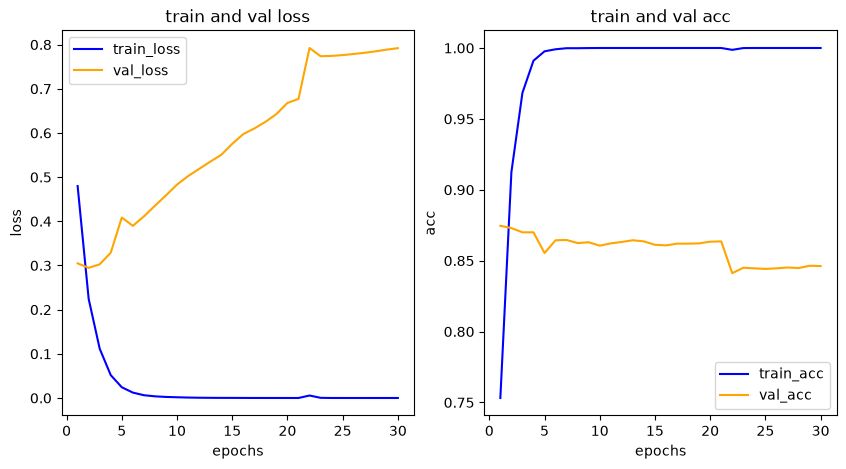

In [28]:
import matplotlib.pyplot as plt

his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize = (10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label = 'train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label = 'val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

# 훈련 및 검증 정확도 그리기
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label = 'train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label = 'val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()